# Covariance estimation

The covariance matrix is the second moment that almost every optimiser depends on, and on a
short window it is badly estimated: with $N$ assets and only a little more than $N$
observations, the sample covariance is noisy and ill-conditioned, and inverting it (as
mean–variance implicitly does) amplifies that noise. Two families of fixes help:

  - **Denoising** — separate signal from noise in the eigenspectrum. `Denoise` offers
    `FixedDenoise` (collapse the sub-threshold bulk), `ShrunkDenoise` (shrink
    it) and `SpectralDenoise` (zero it) — the last does not always lower the condition
    number, as we will see.
  - **Sparsification** — impose a relationship structure on the inverse. `LoGo` keeps
    only the entries justified by the network topology, using a similarity measure such as
    `MaximumDistanceSimilarity` or `ExponentialSimilarity`.

Both are configured through the `MatrixProcessing` pipeline on a
`PortfolioOptimisersCovariance`, which is the `ce` field of a prior.

> **When to reach for this**
>
> Reach for covariance denoising/sparsification whenever your estimation window is short
> relative to the number of assets and you run anything that leans on the covariance —
> mean–variance, risk budgeting, clustering. A lower condition number means a more stable
> inverse and weights that move less when the data wobbles. Compare condition numbers before
> committing to a technique: `SpectralDenoise` in particular can make conditioning
> *worse* on some data.

In [1]:
using PortfolioOptimisers, PrettyTables, LinearAlgebra

mmtfmt = (v, i, j) -> begin
    if j == 1
        return v
    else
        return isa(v, Number) ? "$(round(v, digits=6))" : v
    end
end;
resfmt = (v, i, j) -> begin
    if j == 1
        return v
    else
        return isa(v, Number) ? "$(round(v*100, digits=3)) %" : v
    end
end;

## 1. ReturnsResult data

We use the same S&P 500 slice as the other examples.

In [2]:
using CSV, TimeSeries, DataFrames

X = TimeArray(CSV.File(joinpath(@__DIR__, "..", "SP500.csv.gz")); timestamp = :Date)[(end - 252):end]
rd = prices_to_returns(X)

ReturnsResult
    nx ┼ 20-element Vector{String}
     X ┼ 252×20 Matrix{Float64}
    nf ┼ nothing
     F ┼ nothing
    nb ┼ nothing
     B ┼ nothing
    ts ┼ 252-element Vector{Date}
    iv ┼ nothing
  ivpa ┴ nothing


## 2. Covariance estimators

We build one prior per covariance estimator, varying **only** the `ce` field (the expected
returns are held at the plain sample mean). We compare the vanilla sample covariance against
three denoisers and two LoGo sparsifications.

In [3]:
ces = ["Vanilla" => PortfolioOptimisersCovariance(),
       "FixedDenoise" => PortfolioOptimisersCovariance(;
                                                       mp = MatrixProcessing(;
                                                                             dn = Denoise(;
                                                                                          alg = FixedDenoise()))),
       "ShrunkDenoise" => PortfolioOptimisersCovariance(;
                                                        mp = MatrixProcessing(;
                                                                              dn = Denoise(;
                                                                                           alg = ShrunkDenoise(;
                                                                                                               alpha = 0.5)))),
       "SpectralDenoise" => PortfolioOptimisersCovariance(;
                                                          mp = MatrixProcessing(;
                                                                                dn = Denoise(;
                                                                                             alg = SpectralDenoise()))),
       "LoGo(MaxDist)" =>
           PortfolioOptimisersCovariance(; mp = MatrixProcessing(; alg = LoGo())),
       "LoGo(ExpDist)" => PortfolioOptimisersCovariance(;
                                                        mp = MatrixProcessing(;
                                                                              alg = LoGo(;
                                                                                         sim = ExponentialSimilarity())))]

prs = [k => prior(EmpiricalPrior(; ce = ce), rd) for (k, ce) in ces]

6-element Vector{Pair{String, LowOrderPrior{Matrix{Float64}, Vector{Float64}, Matrix{Float64}, Nothing, Nothing, Nothing, Nothing, Nothing, Nothing, Nothing, Nothing, Nothing}}}:
         "Vanilla" => LowOrderPrior
        X ┼ 252×20 Matrix{Float64}
       mu ┼ 20-element Vector{Float64}
    sigma ┼ 20×20 Matrix{Float64}
     chol ┼ nothing
        w ┼ nothing
      ens ┼ nothing
      kld ┼ nothing
       ow ┼ nothing
       rr ┼ nothing
     f_mu ┼ nothing
  f_sigma ┼ nothing
      f_w ┴ nothing

    "FixedDenoise" => LowOrderPrior
        X ┼ 252×20 Matrix{Float64}
       mu ┼ 20-element Vector{Float64}
    sigma ┼ 20×20 Matrix{Float64}
     chol ┼ nothing
        w ┼ nothing
      ens ┼ nothing
      kld ┼ nothing
       ow ┼ nothing
       rr ┼ nothing
     f_mu ┼ nothing
  f_sigma ┼ nothing
      f_w ┴ nothing

   "ShrunkDenoise" => LowOrderPrior
        X ┼ 252×20 Matrix{Float64}
       mu ┼ 20-element Vector{Float64}
    sigma ┼ 20×20 Matrix{Float64}
     chol ┼ nothing
       

The condition number is our headline diagnostic — lower is better-posed. FixedDenoise gives
the biggest improvement here, while SpectralDenoise actually makes conditioning dramatically
*worse* on this data, a reminder to always measure rather than assume.

In [4]:
pretty_table(DataFrame(; :estimator => [k for (k, _) in prs],
                       Symbol("cond(sigma)") => [cond(p.sigma) for (_, p) in prs]);
             formatters = [mmtfmt], title = "Covariance conditioning by estimator")

   Covariance conditioning by estimator
┌─────────────────┬──────────────────────┐
│       estimator │          cond(sigma) │
│          String │              Float64 │
├─────────────────┼──────────────────────┤
│         Vanilla │           177.278571 │
│    FixedDenoise │            87.203326 │
│   ShrunkDenoise │           135.392386 │
│ SpectralDenoise │ 4.596980750027186e13 │
│   LoGo(MaxDist) │           157.814013 │
│   LoGo(ExpDist) │           159.846418 │
└─────────────────┴──────────────────────┘


## 3. Visualising the eigenspectrum

`plot_eigenspectrum` shows the Marchenko–Pastur $\\lambda_+$ threshold: bars above it
carry signal, bars below are noise. Denoising acts on the sub-threshold bulk.

Eigenspectrum: vanilla sample covariance.

In [5]:
using StatsPlots, GraphRecipes

Eigenspectrum: fixed-denoised covariance.

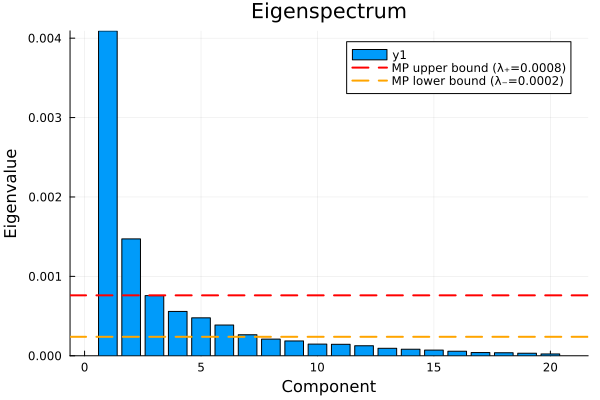

In [6]:
plot_eigenspectrum(prs[1].second, rd)

Eigenspectrum: LoGo(MaxDist) sparsified covariance.

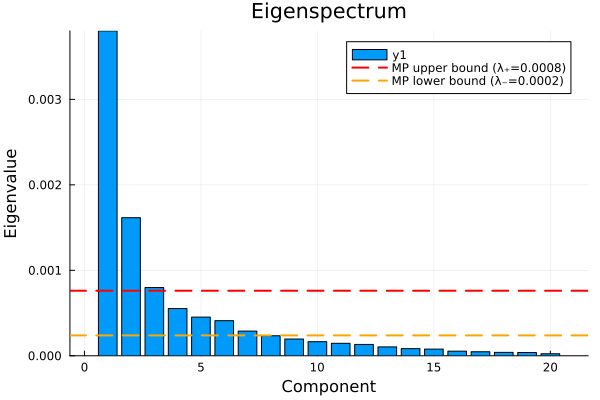

In [7]:
plot_eigenspectrum(prs[2].second, rd)
plot_eigenspectrum(prs[5].second, rd)

## 4. Why it matters: minimum-variance optimisation

Minimum-variance is the optimisation most exposed to covariance conditioning. We solve it with
each prior and compare the weights — better-conditioned estimators produce more stable, less
concentrated allocations.

In [8]:
using Clarabel

slv = Solver(; name = :clarabel1, solver = Clarabel.Optimizer,
             settings = Dict("verbose" => false),
             check_sol = (; allow_local = true, allow_almost = true))

ress = [k => optimise(MeanRisk(; r = Variance(), obj = MinimumRisk(),
                               opt = JuMPOptimiser(; pe = p, slv = slv))) for (k, p) in prs]

pretty_table(DataFrame(["Assets" => rd.nx; [k => r.w for (k, r) in ress]]);
             formatters = [resfmt],
             title = "Minimum-variance weights by covariance estimator")

                Minimum-variance weights by covariance estimator
┌────────┬──────────┬──────────────┬───────────────┬─────────────────┬──────────
│ Assets │  Vanilla │ FixedDenoise │ ShrunkDenoise │ SpectralDenoise │ LoGo(Ma ⋯
│ String │  Float64 │      Float64 │       Float64 │         Float64 │       F ⋯
├────────┼──────────┼──────────────┼───────────────┼─────────────────┼──────────
│   AAPL │    0.0 % │        0.0 % │         0.0 % │           0.0 % │         ⋯
│    AMD │    0.0 % │        0.0 % │         0.0 % │           0.0 % │         ⋯
│    BAC │    0.0 % │        0.0 % │         0.0 % │           0.0 % │         ⋯
│    BBY │    0.0 % │        0.0 % │         0.0 % │           0.0 % │         ⋯
│    CVX │  7.432 % │       8.38 % │       8.324 % │        17.488 % │       7 ⋯
│     GE │  0.806 % │        0.0 % │       1.009 % │           0.0 % │         ⋯
│     HD │    0.0 % │        0.0 % │         0.0 % │           0.0 % │       5 ⋯
│    JNJ │ 36.974 % │     35.168 % │      38

The composition plot contrasts the minimum-variance portfolios across estimators.

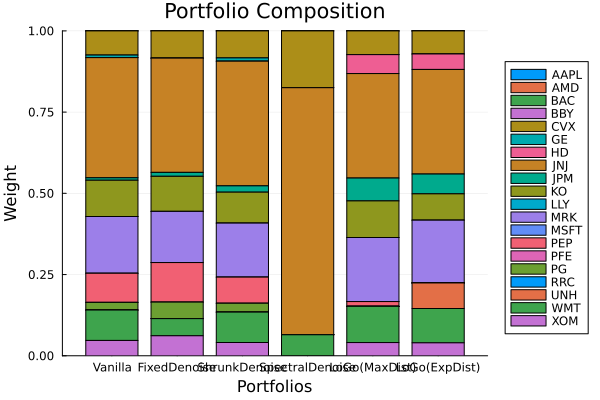

In [9]:
plot_stacked_bar_composition([r for (_, r) in ress], rd;
                             xticks = (1:length(ress), [k for (k, _) in ress]))

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*